In [1]:
# Install lightweight packages
!pip install -q scikit-learn pandas joblib matplotlib

# Create project folders
import os
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("Setup complete!")

Setup complete!


In [2]:
from google.colab import files

print("Click 'Choose Files' and select your CSV dataset:")
uploaded = files.upload()

# See what was uploaded
for filename in uploaded.keys():
    print(f"\nUploaded: {filename}")
    print(f"Size: {len(uploaded[filename])} bytes")

Click 'Choose Files' and select your CSV dataset:


Saving pipeline_leak_dataset.csv to pipeline_leak_dataset.csv

Uploaded: pipeline_leak_dataset.csv
Size: 1276571 bytes


In [3]:
import pandas as pd
import os

# Find the CSV file
csv_file = [f for f in os.listdir() if f.endswith('.csv')][0]
print(f"Loading: {csv_file}")

# Load data
df = pd.read_csv(csv_file)

# Basic info
print(f"\nShape: {df.shape} (rows, columns)")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nAny missing values?")
print(df.isnull().sum())

Loading: pipeline_leak_dataset.csv

Shape: (10000, 10) (rows, columns)

Columns: ['pressure', 'flow_rate', 'temperature', 'vibration', 'acoustic_level', 'pressure_drop', 'flow_anomaly', 'is_leak', 'leak_size', 'leak_location']

First 5 rows:
    pressure   flow_rate  temperature  vibration  acoustic_level  \
0  49.274653  101.793227    24.893077   0.467526       28.398595   
1  51.438196  100.668551    25.299298   0.573857       27.043253   
2  47.618808  100.161335    24.796281   0.586168       20.070757   
3  47.524935  102.169236    25.773517   0.550106       26.613188   
4  50.693106  100.352883    24.816486   0.417241       30.430719   

   pressure_drop  flow_anomaly  is_leak  leak_size  leak_location  
0            0.0           0.0        0        0.0            0.0  
1            0.0           0.0        0        0.0            0.0  
2            0.0           0.0        0        0.0            0.0  
3            0.0           0.0        0        0.0            0.0  
4        

In [4]:
# Show unique values in each column to find the target
print("Unique values per column:")
for col in df.columns:
    unique_vals = df[col].unique()
    if len(unique_vals) < 20:
        print(f"\n{col}: {unique_vals}")
    else:
        print(f"\n{col}: {len(unique_vals)} unique values (numeric)")

Unique values per column:

pressure: 10000 unique values (numeric)

flow_rate: 10000 unique values (numeric)

temperature: 10000 unique values (numeric)

vibration: 10000 unique values (numeric)

acoustic_level: 10000 unique values (numeric)

pressure_drop: 3001 unique values (numeric)

flow_anomaly: 3001 unique values (numeric)

is_leak: [0 1]

leak_size: 3001 unique values (numeric)

leak_location: 3001 unique values (numeric)


In [5]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Using all sensor + engineered features for prediction
features = ['pressure', 'flow_rate', 'temperature', 'vibration',
            'acoustic_level', 'pressure_drop', 'flow_anomaly']

X = df[features]      # Input features
y = df['is_leak']     # Target: 0 = no leak, 1 = leak

# Check class balance
print("Class distribution:")
print(y.value_counts())
print(f"\nLeak percentage: {y.mean()*100:.1f}%")

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Class distribution:
is_leak
0    7000
1    3000
Name: count, dtype: int64

Leak percentage: 30.0%

Training set: 8000 samples
Test set: 2000 samples


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create model
model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    max_depth=10,          # Prevent overfitting
    random_state=42,       # Reproducible results
    n_jobs=-1              # Use all CPU cores
)

print("Training model...")
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability of leak

# Evaluate
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Leak', 'Leak']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training model...

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

     No Leak       1.00      1.00      1.00      1400
        Leak       1.00      1.00      1.00       600

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Confusion Matrix:
[[1400    0]
 [   0  600]]


Feature Importance (what the model uses to decide):
          Feature  Importance
5   pressure_drop    0.309006
6    flow_anomaly    0.232054
4  acoustic_level    0.231830
3       vibration    0.139877
0        pressure    0.067602
1       flow_rate    0.018849
2     temperature    0.000782


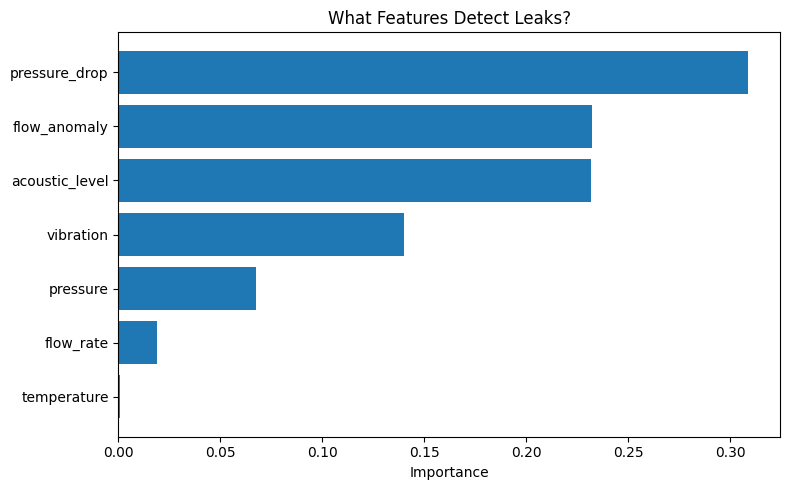

In [7]:
import pandas as pd

# Which features matter most?
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (what the model uses to decide):")
print(importance)

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel('Importance')
plt.title('What Features Detect Leaks?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
import joblib

# Save your trained model
joblib.dump(model, 'my_leak_detector.pkl')
print("Model saved as: my_leak_detector.pkl")

# Also save the feature list (needed for prediction)
import json
with open('features.json', 'w') as f:
    json.dump(features, f)
print("Features saved as: features.json")

# Download link
from google.colab import files
files.download('my_leak_detector.pkl')
files.download('features.json')

Model saved as: my_leak_detector.pkl
Features saved as: features.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import joblib
import json
import pandas as pd

# Load your model
model = joblib.load('my_leak_detector.pkl')

# Load feature list
with open('features.json', 'r') as f:
    features = json.load(f)

print("Features used:", features)
print(f"Model type: {type(model).__name__}")

# Test Case 1: Normal pipeline (no leak)
normal_reading = {
    'pressure': 50.0,
    'flow_rate': 100.0,
    'temperature': 22.0,
    'vibration': 0.5,
    'acoustic_level': 30.0,
    'pressure_drop': 0.0,
    'flow_anomaly': 0.0
}

# Test Case 2: Leak scenario (low pressure, high vibration, high acoustic)
leak_reading = {
    'pressure': 30.0,
    'flow_rate': 85.0,
    'temperature': 25.0,
    'vibration': 1.5,
    'acoustic_level': 55.0,
    'pressure_drop': 15.0,
    'flow_anomaly': 12.0
}

# Test both
for name, reading in [("NORMAL", normal_reading), ("LEAK", leak_reading)]:
    data = pd.DataFrame([reading])
    prediction = model.predict(data)[0]
    probability = model.predict_proba(data)[0]

    print(f"\n{'='*40}")
    print(f"SCENARIO: {name}")
    print(f"{'='*40}")
    print(f"Prediction: {'LEAK DETECTED' if prediction == 1 else 'NO LEAK'}")
    print(f"Leak Probability: {probability[1]*100:.1f}%")
    print(f"No-Leak Probability: {probability[0]*100:.1f}%")

Features used: ['pressure', 'flow_rate', 'temperature', 'vibration', 'acoustic_level', 'pressure_drop', 'flow_anomaly']
Model type: RandomForestClassifier

SCENARIO: NORMAL
Prediction: NO LEAK
Leak Probability: 5.0%
No-Leak Probability: 95.0%

SCENARIO: LEAK
Prediction: LEAK DETECTED
Leak Probability: 100.0%
No-Leak Probability: 0.0%


In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input sliders
pressure = widgets.FloatSlider(value=50, min=0, max=100, step=1, description='Pressure:')
flow_rate = widgets.FloatSlider(value=100, min=0, max=200, step=1, description='Flow Rate:')
temperature = widgets.FloatSlider(value=22, min=0, max=50, step=1, description='Temp:')
vibration = widgets.FloatSlider(value=0.5, min=0, max=5, step=0.1, description='Vibration:')
acoustic = widgets.FloatSlider(value=30, min=0, max=100, step=1, description='Acoustic:')
pressure_drop = widgets.FloatSlider(value=0, min=0, max=50, step=1, description='Press Drop:')
flow_anomaly = widgets.FloatSlider(value=0, min=0, max=50, step=1, description='Flow Anom:')

# Output area
output = widgets.Output()

# Button
button = widgets.Button(description="Analyze Pipeline", button_style='primary')

def on_analyze(b):
    with output:
        clear_output()

        reading = {
            'pressure': pressure.value,
            'flow_rate': flow_rate.value,
            'temperature': temperature.value,
            'vibration': vibration.value,
            'acoustic_level': acoustic.value,
            'pressure_drop': pressure_drop.value,
            'flow_anomaly': flow_anomaly.value
        }

        data = pd.DataFrame([reading])
        pred = model.predict(data)[0]
        prob = model.predict_proba(data)[0]

        print(f"\n{'='*50}")
        if pred == 1:
            print("⚠️  LEAK DETECTED!")
            print(f"Confidence: {prob[1]*100:.1f}%")
        else:
            print("✅ PIPELINE NORMAL")
            print(f"Leak Probability: {prob[1]*100:.1f}%")
        print(f"{'='*50}")

        # Show which features triggered it
        importance = pd.DataFrame({
            'Feature': features,
            'Value': list(reading.values()),
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

        print("\nTop indicators checked:")
        for _, row in importance.head(3).iterrows():
            print(f"  • {row['Feature']}: {row['Value']:.2f}")

button.on_click(on_analyze)

# Display everything
display(widgets.VBox([
    widgets.HBox([pressure, flow_rate]),
    widgets.HBox([temperature, vibration]),
    widgets.HBox([acoustic, pressure_drop]),
    widgets.HBox([flow_anomaly, button]),
    output
]))